## Import

In [2]:
import os
import json
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from pathlib import Path

# Tokenisation
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize

# Transformers
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from datasets import Dataset as HFDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report



# Statistics
from scipy.stats import spearmanr

# OpenAI for HANNA scoring
from openai import OpenAI

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

import matplotlib.pyplot as plt
import seaborn as sns

Device: cuda


## Configuration

In [3]:
custom_dim = ['Narrative Structure','Character&Emotion', 'Originality', 'Immersion', 'Thematic Depth', 'Writing Style',]
hanna_dim= ['Coherence','Empathy', 'Surprise', 'Engagement','Complexity','Relevance',]
mapping = {
    'Narrative Structure': 'Coherence',
    'Character&Emotion':   'Empathy',
    'Originality':         'Surprise',
    'Immersion':           'Engagement',
    'Thematic Depth':      'Complexity',
    'Writing Style':       'Relevance',
}

MODEL_NAME    = 'microsoft/deberta-v3-base'
MAX_LEN       = 128
BATCH_SIZE    = 16
NUM_EPOCHS    = 10
LR            = 2e-5

DATA_DIR      = Path('/user/HS402/kk01697/Documents/dissertation/story-evaluation-dissertation/data/raw/goodreads')
OUTPUT_DIR    = Path('/user/HS402/kk01697/Documents/dissertation/story-evaluation-dissertation/outputs')
MODEL_DIR     = OUTPUT_DIR / 'deberta_classifier'

## Load and Clean Data

In [4]:
books_file = "/user/HS402/kk01697/Documents/dissertation/story-evaluation-dissertation/data/raw/goodreads/goodreads_books_fantasy_paranormal.json"
reviews_file = "/user/HS402/kk01697/Documents/dissertation/story-evaluation-dissertation/data/raw/goodreads/goodreads_reviews_fantasy_paranormal.json"

books = []
with open(books_file, "r") as f:
    for line in tqdm(f):
        books.append(json.loads(line))
book_df = pd.DataFrame(books)
print(book_df.shape)
book_df.head()


reviews = []
with open(reviews_file, "r") as f:
    for line in tqdm(f):
        reviews.append(json.loads(line))
review_df = pd.DataFrame(reviews)
print(review_df.shape)
review_df.head()

merged = review_df.merge(book_df, on='book_id', how='inner')

0it [00:00, ?it/s]

(258585, 29)


0it [00:00, ?it/s]

(3424641, 11)


In [5]:
def basic_filter(df: pd.DataFrame,min_words: int = 30, min_rating: int = 1, max_rating: int = 5) -> pd.DataFrame:
    """ Remove empty / very short reviews and invalid ratings. """
    english_codes = ["eng", "en-UK", "en-US", "en-AUS"]

    df = df[df["language_code"].isin(english_codes)]
    df = df.dropna(subset=["review_text", "rating"])
    df = df[df["review_text"].str.split().str.len() >= min_words]
    df = df[df["rating"].between(min_rating, max_rating)]
    df = df.drop_duplicates(subset=["review_text"])
    df = df.reset_index(drop=True)
    return df

df_raw = merged
df = basic_filter(df_raw)
print(f"Loaded {len(df_raw):,} rows → {len(df):,} after filtering")

Loaded 3,424,641 rows → 1,903,442 after filtering


## Tokenize

In [6]:
def tokenise_reviews(df: pd.DataFrame) -> pd.DataFrame:
    """
    Explode each review into one row per sentence.
    Returns columns: review_id, sentence_idx, sentence, rating, language_code
    """
    rows = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Tokenising"):
        sentences = sent_tokenize(row["review_text"])
        # Drop very short sentences (< 5 words) — often noise
        sentences = [s.strip() for s in sentences if len(s.split()) >= 5]
        for idx, sent in enumerate(sentences):
            rows.append({
                "review_id":    row["review_id"],
                "sentence_idx": idx,
                "sentence":     sent,
                "rating":       row["rating"],
                "language":  row["language_code"],
            })
    return pd.DataFrame(rows)

df_sents = tokenise_reviews(df)
print(f"{len(df_sents):,} sentences from {df['review_id'].nunique():,} reviews")
#df_sents.head(4)

Tokenising:   0%|          | 0/1903442 [00:00<?, ?it/s]

20,275,427 sentences from 1,903,442 reviews


In [13]:
def load_annotations(path: str | Path) -> pd.DataFrame:
    """Load annotated sentences exported from Label Studio or Doccano.

    Expected columns: sentence, plus one binary column per dimension in CUSTOM_DIMS.
    Accepts .csv or .json (list of dicts).
    """
    path = Path(path)
    if path.suffix == '.json':
        with open(path) as f:
            raw = json.load(f)
        df = pd.DataFrame(raw)
    else:
        df = pd.read_csv(path)

    missing = [d for d in custom_dim if d not in df.columns]
    if missing:
        raise ValueError(f'Annotation file is missing dimension columns: {missing}')

    df[custom_dim] = df[custom_dim].fillna(0).astype(int)
    return df


def summarise_annotations(df: pd.DataFrame) -> pd.DataFrame:
    """Print class distribution and flag dimensions below the 200-sentence threshold."""
    counts = df[custom_dim].sum().rename('positive_count')
    total = len(df)
    summary = counts.to_frame()
    summary['proportion'] = (summary['positive_count'] / total).round(3)
    summary['below_threshold'] = summary['positive_count'] < 200
    print(f'Total annotated sentences: {total}')
    print(summary.to_string())
    return summary

# ── Synthetic demo dataset (replace with real annotation file path) ────────────
np.random.seed(SEED)
n_sentences = 1500
probabilities = {
    'Narrative Structure': 0.40,
    'Character&Emotion':   0.35,
    'Originality':         0.15,  # class imbalance flagged
    'Immersion':           0.20,  # class imbalance flagged
    'Thematic Depth':      0.25,
    'Writing Style':       0.30,
}

demo_labels = {dim: np.random.binomial(1, p, n_sentences) for dim, p in probabilities.items()}
demo_df = pd.DataFrame({'sentence': [f'Sentence {i}' for i in range(n_sentences)], **demo_labels})
demo_df.to_csv(DATA_DIR / 'demo_annotations.csv', index=False)

ann_df = load_annotations(DATA_DIR / 'demo_annotations.csv')
summarise_annotations(ann_df)

Total annotated sentences: 1500
                     positive_count  proportion  below_threshold
Narrative Structure             613       0.409            False
Character&Emotion               530       0.353            False
Originality                     191       0.127             True
Immersion                       308       0.205            False
Thematic Depth                  365       0.243            False
Writing Style                   403       0.269            False


,positive_count,proportion,below_threshold
Narrative Structure,613,0.409,False
Character&Emotion,530,0.353,False
Originality,191,0.127,True
Immersion,308,0.205,False
Thematic Depth,365,0.243,False
Writing Style,403,0.269,False


## Train Classifier

In [7]:
class SentenceDataset(Dataset):
    def __init__(self, sentences: list[str], labels: np.ndarray, tokenizer, max_len: int = MAX_LEN):
        self.encodings = tokenizer(
            sentences,
            truncation=True,
            padding='max_length',
            max_length=max_len,
            return_tensors='pt',
        )
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         self.labels[idx],
        }


def build_compute_metrics(threshold: float = 0.5):
    """Returns a compute_metrics function for the HF Trainer.

    Reports micro-F1, macro-F1, and per-dimension F1.
    """
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        probs = 1 / (1 + np.exp(-logits))  # sigmoid
        preds = (probs >= threshold).astype(int)

        micro_f1 = f1_score(labels, preds, average='micro', zero_division=0)
        macro_f1 = f1_score(labels, preds, average='macro', zero_division=0)
        per_dim  = f1_score(labels, preds, average=None, zero_division=0)

        metrics = {'f1_micro': micro_f1, 'f1_macro': macro_f1}
        for dim, score in zip(custom_dim, per_dim):
            metrics[f'f1_{dim}'] = score
        return metrics
    return compute_metrics


def train_classifier(
    ann_df: pd.DataFrame,
    model_dir: Path = MODEL_DIR,
    test_size: float = 0.15,
    val_size: float = 0.15,
):
    """Fine-tune DeBERTa-v3-base as a multi-label sentence classifier.

    Args:
        ann_df: DataFrame with 'sentence' column and one binary column per CUSTOM_DIM.
        model_dir: Where to save the fine-tuned model.
        test_size: Fraction held out for final test evaluation.
        val_size: Fraction of remaining data used for validation during training.

    Returns:
        Trained Trainer object.
    """
    sentences = ann_df['sentence'].tolist()
    labels    = ann_df[custom_dim].values.astype(np.float32)

    # Split: train / val / test
    idx = np.arange(len(sentences))
    idx_trainval, idx_test = train_test_split(idx, test_size=test_size, random_state=SEED)
    idx_train, idx_val     = train_test_split(idx_trainval, test_size=val_size, random_state=SEED)

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    train_ds = SentenceDataset([sentences[i] for i in idx_train], labels[idx_train], tokenizer)
    val_ds   = SentenceDataset([sentences[i] for i in idx_val],   labels[idx_val],   tokenizer)
    test_ds  = SentenceDataset([sentences[i] for i in idx_test],  labels[idx_test],  tokenizer)

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(custom_dim),
        problem_type='multi_label_classification',  # triggers BCE + sigmoid internally
    )

    training_args = TrainingArguments(
        output_dir=str(model_dir),
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        learning_rate=LR,
        weight_decay=0.01,
        evaluation_strategy='epoch',
        save_strategy='best',
        load_best_model_at_end=True,
        metric_for_best_model='f1_macro',
        logging_steps=50,
        seed=SEED,
        fp16=DEVICE == 'cuda',
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=build_compute_metrics(),
    )

    trainer.train()
    tokenizer.save_pretrained(model_dir)

    # Final evaluation on held-out test set
    test_results = trainer.evaluate(test_ds)
    print('\n── Test-set evaluation ──')
    for k, v in test_results.items():
        print(f'  {k}: {v:.4f}')

    return trainer



##print('Step 3 functions defined. Call train_classifier(ann_df) to begin fine-tuning.')
print(f'Model will be saved to: {MODEL_DIR}')
# Uncomment to run (requires GPU for practical turnaround):
# trainer = train_classifier(ann_df)

Model will be saved to: /user/HS402/kk01697/Documents/dissertation/story-evaluation-dissertation/outputs/deberta_classifier


### Train the classifier

In [8]:
def load_classifier(model_dir: Path = MODEL_DIR):
    """Load fine-tuned tokenizer and model from disk."""
    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    model = AutoModelForSequenceClassification.from_pretrained(model_dir).to(DEVICE)
    model.eval()
    return tokenizer, model


def predict_sentences(
    sentences: list[str],
    tokenizer,
    model,
    threshold: float = 0.5,
    batch_size: int = 64,
) -> np.ndarray:
    """Run multi-label inference on a list of sentences.

    Returns:
        Binary array of shape (n_sentences, n_dims).
    """
    all_preds = []
    for i in range(0, len(sentences), batch_size):
        batch = sentences[i : i + batch_size]
        enc = tokenizer(
            batch,
            truncation=True,
            padding=True,
            max_length=MAX_LEN,
            return_tensors='pt',
        ).to(DEVICE)
        with torch.no_grad():
            logits = model(**enc).logits
        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs >= threshold).astype(int)
        all_preds.append(preds)
    return np.vstack(all_preds)


def classify_reviews(
    reviews_df: pd.DataFrame,
    tokenizer,
    model,
    text_col: str = 'review_text',
    id_col: str = 'review_id',
    threshold: float = 0.5,
) -> pd.DataFrame:
    """Tokenise reviews and run classifier on each sentence.

    Returns:
        Long-form DataFrame: review_id, sentence_idx, sentence, + one binary column per CUSTOM_DIM.
    """
    sentences_df = tokenise_corpus(reviews_df, text_col=text_col, id_col=id_col)
    preds = predict_sentences(
        sentences_df['sentence'].tolist(),
        tokenizer,
        model,
        threshold=threshold,
    )
    pred_df = pd.DataFrame(preds, columns=custom_dim)
    return pd.concat([sentences_df.reset_index(drop=True), pred_df], axis=1)


# Demonstrate expected output shape with dummy predictions
dummy_sentences_df = pd.DataFrame({
    'review_id': [1, 1, 1, 2, 2],
    'sentence_idx': [0, 1, 2, 0, 1],
    'sentence': [
        'The world-building is extraordinary.',
        'I was completely absorbed for three days.',
        'The protagonist felt a bit rushed.',
        'This book changed how I think about magic.',
        'Pacing was slow but worth it in the end.',
    ],
})
np.random.seed(SEED)
dummy_preds = np.random.randint(0, 2, (5, 6))
dummy_out = pd.concat([dummy_sentences_df, pd.DataFrame(dummy_preds, columns=custom_dim)], axis=1)
print('Sample sentence-level predictions:')
print(dummy_out.to_string(index=False))

Sample sentence-level predictions:
 review_id  sentence_idx                                   sentence  Narrative Structure  Character&Emotion  Originality  Immersion  Thematic Depth  Writing Style
         1             0       The world-building is extraordinary.                    0                  1            0          0               0              1
         1             1  I was completely absorbed for three days.                    0                  0            0          1               0              0
         1             2         The protagonist felt a bit rushed.                    0                  0            1          0               1              1
         2             0 This book changed how I think about magic.                    1                  0            1          0               1              1
         2             1   Pacing was slow but worth it in the end.                    1                  1            1          1               1   

## Aggregate the review vector

In [9]:
def aggregate_to_review_scores(
    sentence_preds_df: pd.DataFrame,
    id_col: str = 'review_id',
) -> pd.DataFrame:
    """Aggregate sentence-level binary labels to review-level proportion scores.

    Proportion score = (# sentences with label) / (total sentences in review).
    Score is continuous in [0, 1]; higher means the dimension is more dominant.

    Returns:
        DataFrame with one row per review_id and one column per CUSTOM_DIM.
    """
    grouped = sentence_preds_df.groupby(id_col)
    proportion_scores = grouped[custom_dim].mean()  # mean of binary = proportion
    proportion_scores.columns = [f'prop_{d}' for d in custom_dim]

    # Also store sentence count as a diagnostic
    proportion_scores['sentence_count'] = grouped['sentence_idx'].count()
    return proportion_scores.reset_index()


# Demo with the dummy predictions from Step 4
review_scores = aggregate_to_review_scores(dummy_out)
print('Review-level proportion scores:')
print(review_scores.round(3).to_string(index=False))

Review-level proportion scores:
 review_id  prop_Narrative Structure  prop_Character&Emotion  prop_Originality  prop_Immersion  prop_Thematic Depth  prop_Writing Style  sentence_count
         1                       0.0                   0.333             0.333           0.333                0.333               0.667               3
         2                       1.0                   0.500             1.000           0.500                1.000               1.000               2


## LLM Scoring

In [10]:
HANNA_SCORING_SYSTEM_PROMPT = """\
You are an expert literary evaluator. Given a book review, score the review on each of the 
following six HANNA narrative quality dimensions using a 1–5 integer scale.

Dimension definitions:
- Coherence (1–5): Does the reviewer indicate the narrative holds together logically and structurally?
- Empathy (1–5): Does the reviewer respond to characters with emotional connection or investment?
- Surprise (1–5): Does the reviewer note originality, unpredictability, or subverted expectations?
- Engagement (1–5): Does the review convey that the reviewer was absorbed, immersed, or compelled?
- Complexity (1–5): Does the reviewer address thematic depth, layering, or intellectual richness?
- Relevance (1–5): Does the review comment on the quality or appropriateness of the writing style?

Score 1 = absent/very weak, 3 = moderate, 5 = strong/dominant.

Respond ONLY with a JSON object in this exact format, no preamble:
{"Coherence": <int>, "Empathy": <int>, "Surprise": <int>, 
 "Engagement": <int>, "Complexity": <int>, "Relevance": <int>}
"""

FEW_SHOT_EXAMPLES = [
    {
        'role': 'user',
        'content': (
            'Review: "The plot threads all come together in the final act in a way that felt '
            'completely inevitable yet surprising. I wept for the side characters as much as '
            'the leads. The magic system is unlike anything I have read before. I could not '
            'put this down for four days. The themes of grief and identity run deep. '
            'The prose is clean and invisible — it never gets in the way."'
        ),
    },
    {
        'role': 'assistant',
        'content': json.dumps({
            'Coherence': 5, 'Empathy': 5, 'Surprise': 5,
            'Engagement': 5, 'Complexity': 5, 'Relevance': 4,
        }),
    },
    {
        'role': 'user',
        'content': (
            'Review: "It was okay. The story moved along fine but nothing really stood out. '
            'Characters were generic. Not very original but not bad either. '
            'The writing was average."'
        ),
    },
    {
        'role': 'assistant',
        'content': json.dumps({
            'Coherence': 3, 'Empathy': 2, 'Surprise': 2,
            'Engagement': 2, 'Complexity': 1, 'Relevance': 2,
        }),
    },
]


def score_review_hanna(
    review_text: str,
    client: OpenAI,
    model: str = 'gpt-4o',
    retries: int = 2,
) -> dict | None:
    """Score a single review on HANNA dimensions via GPT-4o few-shot prompting.

    Returns:
        Dict of {dimension: int score} or None on failure.
    """
    messages = [
        {'role': 'system', 'content': HANNA_SCORING_SYSTEM_PROMPT},
        *FEW_SHOT_EXAMPLES,
        {'role': 'user', 'content': f'Review: "{review_text}"'},
    ]

    for attempt in range(retries + 1):
        try:
            resp = client.chat.completions.create(
                model=model,
                messages=messages,
                temperature=0.0,
                response_format={'type': 'json_object'},
            )
            raw = resp.choices[0].message.content
            scores = json.loads(raw)
            # Validate keys and clamp values
            validated = {}
            for dim in hanna_dim:
                val = int(scores.get(dim, 3))
                validated[dim] = max(1, min(5, val))
            return validated
        except Exception as e:
            if attempt == retries:
                print(f'HANNA scoring failed after {retries + 1} attempts: {e}')
                return None


def score_corpus_hanna(
    reviews_df: pd.DataFrame,
    client: OpenAI,
    text_col: str = 'review_text',
    id_col: str = 'review_id',
    model: str = 'gpt-4o',
) -> pd.DataFrame:
    """Score all reviews in a DataFrame on HANNA dimensions.

    Returns:
        DataFrame with review_id and one column per HANNA_DIM (scores 1–5).
    """
    results = []
    for _, row in tqdm(reviews_df.iterrows(), total=len(reviews_df), desc='HANNA scoring'):
        scores = score_review_hanna(row[text_col], client, model=model)
        if scores is not None:
            scores[id_col] = row[id_col]
            results.append(scores)
    result_df = pd.DataFrame(results)
    cols = [id_col] + hanna_dim
    return result_df[cols]


# Demo: print prompt structure
print('GPT-4o scoring prompt structure:')
print(f'  System message: {len(HANNA_SCORING_SYSTEM_PROMPT.split())} words')
print(f'  Few-shot turns: {len(FEW_SHOT_EXAMPLES) // 2} examples')
print(f'  Output format: JSON object with keys {hanna_dim}')

# Uncomment to run (requires OPENAI_API_KEY):
# client = OpenAI(api_key=os.environ['OPENAI_API_KEY'])
# hanna_scores_df = score_corpus_hanna(reviews_df, client)

GPT-4o scoring prompt structure:
  System message: 149 words
  Few-shot turns: 2 examples
  Output format: JSON object with keys ['Coherence', 'Empathy', 'Surprise', 'Engagement', 'Complexity', 'Relevance']


## Validation

Spearman ρ matrix (custom dims × HANNA dims):
                     Coherence  Empathy  Surprise  Engagement  Complexity  Relevance
Narrative Structure      0.849   -0.060    -0.037      -0.022       0.066      0.089
Character&Emotion       -0.140    0.830    -0.042      -0.070       0.127     -0.053
Originality             -0.044    0.040     0.851      -0.046       0.013      0.037
Immersion               -0.045   -0.087    -0.027       0.815      -0.004      0.105
Thematic Depth           0.066    0.087     0.054       0.002       0.867     -0.002
Writing Style            0.180   -0.118     0.075       0.010       0.063      0.835

Primary-mapping validation summary:
         custom_dim  hanna_dim  spearman_rho  weak_signal
     Thematic Depth Complexity         0.867        False
        Originality   Surprise         0.851        False
Narrative Structure  Coherence         0.849        False
      Writing Style  Relevance         0.835        False
  Character&Emotion    Empathy  

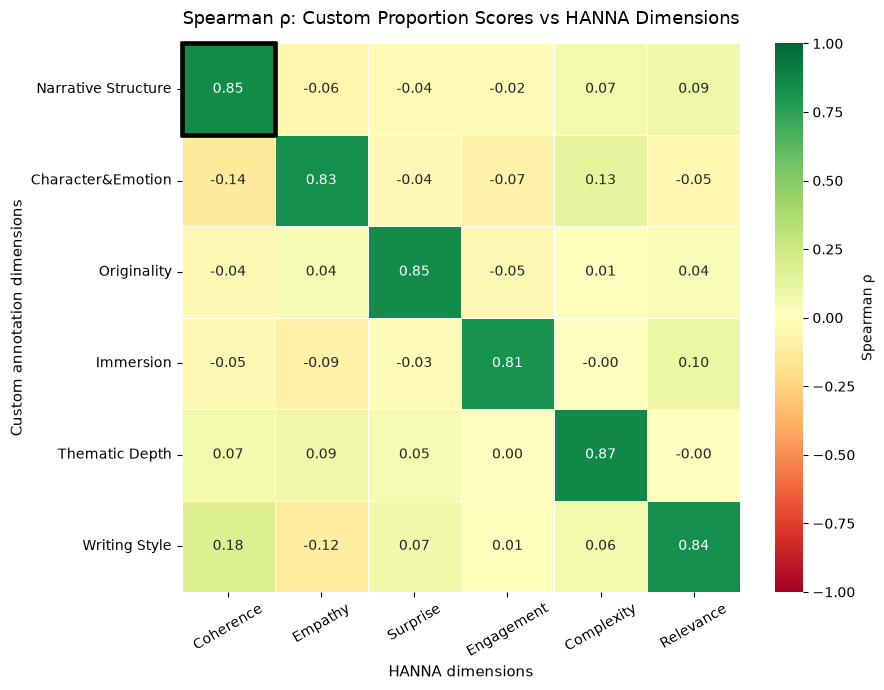

In [11]:
def compute_spearman_matrix(
    proportion_df: pd.DataFrame,
    hanna_df: pd.DataFrame,
    id_col: str = 'review_id',
) -> pd.DataFrame:
    """Compute Spearman correlation matrix (custom dims × HANNA dims).

    Args:
        proportion_df: Output of aggregate_to_review_scores(); must contain review_id.
        hanna_df: Output of score_corpus_hanna(); must contain review_id.

    Returns:
        6×6 DataFrame of Spearman ρ values.
    """
    merged = proportion_df.merge(hanna_df, on=id_col)
    prop_cols  = [f'prop_{d}' for d in custom_dim]
    hanna_cols = hanna_dim

    matrix = np.zeros((len(custom_dim), len(hanna_dim)))
    for i, pc in enumerate(prop_cols):
        for j, hc in enumerate(hanna_cols):
            rho, _ = spearmanr(merged[pc], merged[hc])
            matrix[i, j] = rho

    return pd.DataFrame(
        matrix,
        index=custom_dim,
        columns=hanna_dim,
    )


def plot_correlation_matrix(
    corr_df: pd.DataFrame,
    title: str = 'Spearman ρ: Custom Proportion Scores vs HANNA Dimensions',
    save_path: Path | None = None,
):
    """Plot the 6×6 Spearman correlation heatmap with primary-mapping diagonal annotated."""
    fig, ax = plt.subplots(figsize=(9, 7))

    sns.heatmap(
        corr_df,
        annot=True,
        fmt='.2f',
        cmap='RdYlGn',
        vmin=-1, vmax=1,
        linewidths=0.5,
        ax=ax,
        cbar_kws={'label': 'Spearman ρ'},
    )

    # Highlight primary-mapping cells with a box
    for custom_dim, hanna_dim in mapping.items():
        row_idx = custom_dim.index(custom_dim)
        col_idx = hanna_dim.index(hanna_dim)
        ax.add_patch(plt.Rectangle(
            (col_idx, row_idx), 1, 1,
            fill=False, edgecolor='black', lw=2.5, clip_on=False,
        ))

    ax.set_title(title, fontsize=13, pad=14)
    ax.set_xlabel('HANNA dimensions', fontsize=11)
    ax.set_ylabel('Custom annotation dimensions', fontsize=11)
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.show()


def summarise_validation(corr_df: pd.DataFrame) -> pd.DataFrame:
    """Extract primary-mapping Spearman ρ values and flag weak correlations.

    A correlation below 0.3 on the primary mapping is a validation concern.
    """
    rows = []
    for custom_dim, hanna_dim in mapping.items():
        rho = corr_df.loc[custom_dim, hanna_dim]
        rows.append({
            'custom_dim':   custom_dim,
            'hanna_dim':    hanna_dim,
            'spearman_rho': round(rho, 3),
            'weak_signal':  abs(rho) < 0.3,
        })
    return pd.DataFrame(rows).sort_values('spearman_rho', ascending=False)


# ── Demo with synthetic scores ─────────────────────────────────────────────────
# Simulate review-level proportion scores and HANNA scores for illustration
np.random.seed(SEED)
n_reviews = 200
review_ids = np.arange(n_reviews)

# Synthetic proportion scores: moderately correlated with their primary HANNA dim
latent = np.random.randn(n_reviews, 6)
noise  = np.random.randn(n_reviews, 6) * 0.7
prop_values = np.clip(latent * 0.3 + 0.35 + noise * 0.1, 0, 1)
hanna_values = np.clip(latent * 0.8 + 3.0 + noise, 1, 5)

demo_prop_df = pd.DataFrame(prop_values, columns=[f'prop_{d}' for d in custom_dim])
demo_prop_df.insert(0, 'review_id', review_ids)

demo_hanna_df = pd.DataFrame(np.round(hanna_values).clip(1, 5).astype(int), columns=hanna_dim)
demo_hanna_df.insert(0, 'review_id', review_ids)

corr_df = compute_spearman_matrix(demo_prop_df, demo_hanna_df)

print('Spearman ρ matrix (custom dims × HANNA dims):')
print(corr_df.round(3).to_string())

print('\nPrimary-mapping validation summary:')
print(summarise_validation(corr_df).to_string(index=False))

plot_correlation_matrix(
    corr_df,
    save_path=OUTPUT_DIR / 'spearman_heatmap_demo.png',
)

### validate against HANNA scores:

In [12]:
def validate_against_hanna_benchmark(
    proportion_df: pd.DataFrame,
    benchmark_df: pd.DataFrame,
    id_col: str = 'review_id',
) -> pd.DataFrame:
    """Correlate proportion scores against ground-truth HANNA benchmark ratings.

    Args:
        proportion_df: Output of aggregate_to_review_scores().
        benchmark_df: DataFrame with review_id and HANNA dimension ratings
                      drawn from the original HANNA dataset.

    Returns:
        6×6 Spearman correlation DataFrame.
    """
    missing_hanna = [d for d in hanna_dim if d not in benchmark_df.columns]
    if missing_hanna:
        raise ValueError(f'Benchmark DataFrame is missing columns: {missing_hanna}')

    corr_df = compute_spearman_matrix(proportion_df, benchmark_df, id_col=id_col)
    print('Benchmark validation — Spearman ρ matrix:')
    print(corr_df.round(3).to_string())
    return corr_df


# Uncomment and supply your held-out benchmark DataFrame:
# benchmark_df = pd.read_csv('data/hanna_heldout.csv')
# benchmark_corr = validate_against_hanna_benchmark(review_scores, benchmark_df)
# plot_correlation_matrix(benchmark_corr, title='Spearman ρ vs HANNA Benchmark Ratings')

print('Benchmark validation cell ready. Supply hanna_heldout.csv to run.')

Benchmark validation cell ready. Supply hanna_heldout.csv to run.


## Run the pipeline - OBJECTIVE 1

In [ ]:
def run_objective1_pipeline(
    reviews_path: str,
    annotations_path: str,
    openai_api_key: str,
    text_col: str = 'review_text',
    id_col: str = 'review_id',
    retrain: bool = False,
) -> dict:
    """End-to-end Objective 1 pipeline.

    Args:
        reviews_path: Path to Goodreads reviews CSV.
        annotations_path: Path to annotated sentences CSV (Step 2 output).
        openai_api_key: OpenAI API key for HANNA scoring.
        text_col: Column name for review text in reviews CSV.
        id_col: Column name for review ID in reviews CSV.
        retrain: If True, retrain the classifier even if a saved model exists.

    Returns:
        Dict containing proportion_df, hanna_scores_df, corr_df.
    """
    print('── Loading data ──────────────────────────────────────')
    reviews_df = pd.read_csv(reviews_path)
    ann_df     = load_annotations(annotations_path)
    summarise_annotations(ann_df)

    print('\n── Step 3: Training classifier ───────────────────────')
    if retrain or not MODEL_DIR.exists():
        train_classifier(ann_df)
    else:
        print(f'Loaded existing model from {MODEL_DIR}')

    print('\n── Step 4: Running classifier on reviews ─────────────')
    tokenizer, model = load_classifier()
    sentence_preds_df = classify_reviews(reviews_df, tokenizer, model,text_col=text_col, id_col=id_col)

    print('\n── Step 5: Aggregating to review scores ──────────────')
    proportion_df = aggregate_to_review_scores(sentence_preds_df, id_col=id_col)
    proportion_df.to_parquet(OUTPUT_DIR / 'proportion_scores.parquet', index=False)
    print(f'Saved proportion scores: {OUTPUT_DIR / "proportion_scores.parquet"}')

    print('\n── Step 6: GPT-4o HANNA scoring ──────────────────────')
    client = OpenAI(api_key=openai_api_key)
    hanna_scores_df = score_corpus_hanna(reviews_df, client,
                                         text_col=text_col, id_col=id_col)
    hanna_scores_df.to_parquet(OUTPUT_DIR / 'hanna_scores.parquet', index=False)
    print(f'Saved HANNA scores: {OUTPUT_DIR / "hanna_scores.parquet"}')

    print('\n── Step 7: Spearman validation ───────────────────────')
    corr_df = compute_spearman_matrix(proportion_df, hanna_scores_df, id_col=id_col)
    print(corr_df.round(3).to_string())
    plot_correlation_matrix(corr_df, save_path=OUTPUT_DIR / 'spearman_heatmap.png')

    print('\n── Validation summary ────────────────────────────────')
    print(summarise_validation(corr_df).to_string(index=False))

    # Final output for Objective 2
    final_df = proportion_df.merge(hanna_scores_df, on=id_col)
    final_df.to_parquet(OUTPUT_DIR / 'final_quality_profiles.parquet', index=False)
    print(f'\nFinal quality profiles saved: {OUTPUT_DIR / "final_quality_profiles.parquet"}')

    return {
        'proportion_df':   proportion_df,
        'hanna_scores_df': hanna_scores_df,
        'corr_df':         corr_df,
    }


print('Pipeline runner defined.')
print('To execute the full pipeline:')
print("    results = run_objective1_pipeline(")
print("        reviews_path='data/goodreads_reviews.csv',")
print("        annotations_path='data/annotations.csv',")
print("        openai_api_key=os.environ['OPENAI_API_KEY'],")
print("    )")